# 📘 Week 14: Embedded DSP & Hardware Constraints
Welcome to Week 14 of the **Signal Processing Roadmap**! In this module, we shift our focus from theoretical floating-point algorithms to the practical constraints of deploying DSP on physical hardware (e.g., microcontrollers, FPGAs, and embedded processors).

We will study **fixed-point arithmetic**, analyze the spectral degradation caused by **coefficient quantization**, and implement a **circular buffer** for sample-by-sample real-time streaming processing.

## 🎯 Learning Objectives:
- Understand the differences between floating-point and fixed-point representations ($Q$-format).
- Simulate quantization noise, overflow saturation, and truncation in fixed-point math.
- Analyze the frequency response degradation of FIR filters under 8-bit and 16-bit coefficient quantization.
- Implement a circular buffer in Python and perform real-time sample-by-sample streaming DSP.

## 1. Fixed-Point Arithmetic Simulation ($Q$-Format)
Most low-cost microcontrollers do not have a hardware Floating Point Unit (FPU), or they process fixed-point arithmetic much faster. In fixed-point representation, a float $x$ is converted to a scaled integer $X$ using a $Q_{I.F}$ format (where $I$ is the number of integer bits, and $F$ is the number of fractional bits):
$$X = \text{round}(x \cdot 2^F)$$

For example, in a signed 16-bit integer representation, we can choose $Q_{2.13}$ (1 sign bit, 2 integer bits, 13 fractional bits):
- Range: $[-2^2, 2^2 - 2^{-13}] = [-4.0, 3.9995]$
- Resolution (LSB): $2^{-13} \approx 0.000122$

Let's write helper functions to simulate fixed-point operations, handling **quantization**, **saturation (clipping)**, and **underflow (precision loss)**.

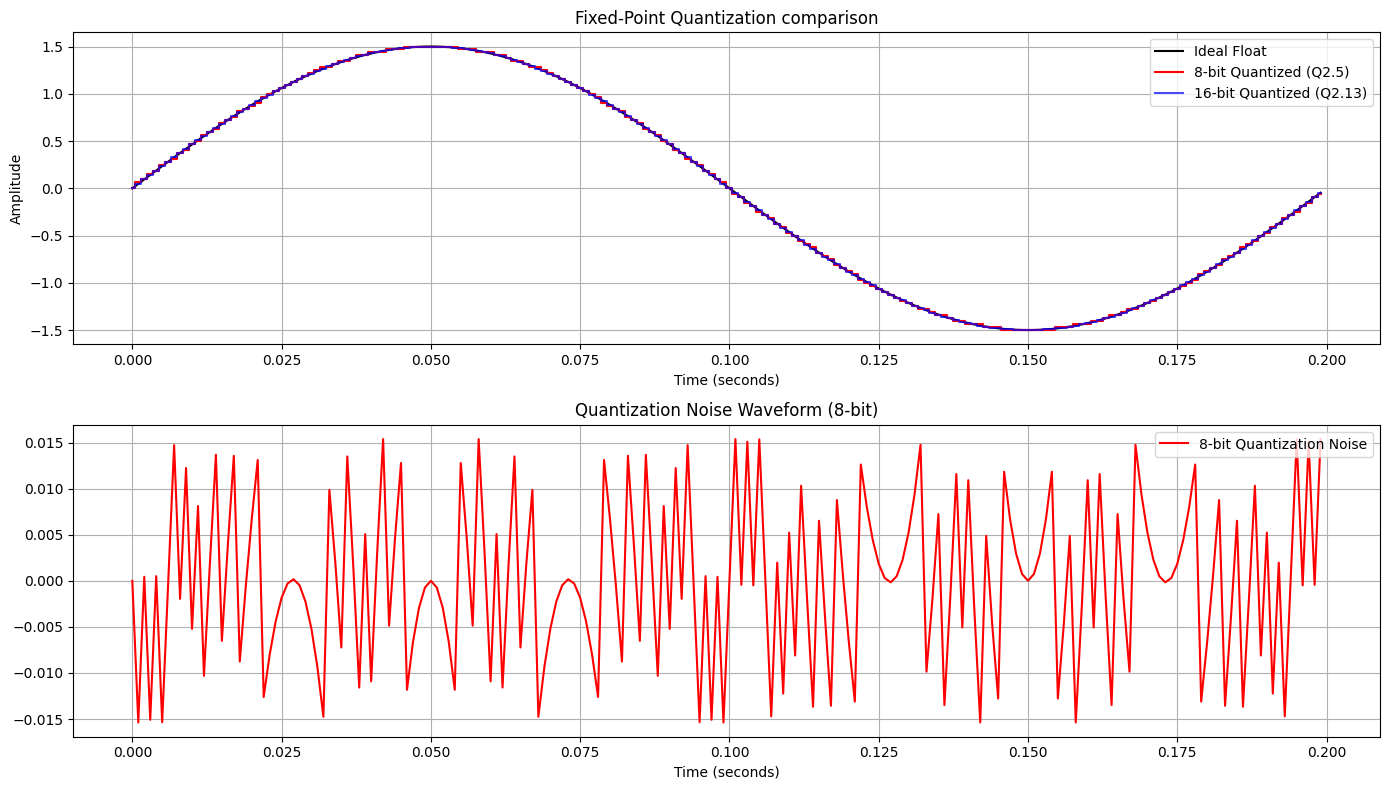

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

class FixedPointQ:
    def __init__(self, int_bits, frac_bits):
        self.I = int_bits
        self.F = frac_bits
        self.total_bits = 1 + int_bits + frac_bits # +1 for sign bit
        self.scale = 2 ** self.F
        # Max/Min representable values for signed integer
        self.max_val = (2 ** (self.total_bits - 1) - 1) / self.scale
        self.min_val = -(2 ** (self.total_bits - 1)) / self.scale

    def float_to_fixed(self, x):
        # Scale and round to nearest integer
        scaled = np.round(x * self.scale)
        # Saturation logic (Overflow protection)
        clamped = np.clip(scaled, self.min_val * self.scale, self.max_val * self.scale)
        return clamped.astype(np.int64)

    def fixed_to_float(self, X):
        return X / self.scale

    def quantize(self, x):
        return self.fixed_to_float(self.float_to_fixed(x))

# 1. Simulate a signal quantized at different bit depths
t = np.linspace(0, 1.0, 1000, endpoint=False)
x_float = 1.5 * np.sin(2 * np.pi * 5 * t)

# High-resolution (16-bit equivalent: Q2.13)
q_16 = FixedPointQ(int_bits=2, frac_bits=13)
x_q16 = q_16.quantize(x_float)

# Low-resolution (8-bit equivalent: Q2.5)
q_8 = FixedPointQ(int_bits=2, frac_bits=5)
x_q8 = q_8.quantize(x_float)

# Calculate Quantization Error / Noise
noise_q8 = x_float - x_q8

# Plotting
plt.figure(figsize=(14, 8))
plt.subplot(2, 1, 1)
plt.plot(t[:200], x_float[:200], 'black', label='Ideal Float', linewidth=1.5)
plt.step(t[:200], x_q8[:200], 'red', label='8-bit Quantized (Q2.5)', where='mid')
plt.step(t[:200], x_q16[:200], 'blue', label='16-bit Quantized (Q2.13)', where='mid', alpha=0.7)
plt.title("Fixed-Point Quantization comparison")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t[:200], noise_q8[:200], 'red', label='8-bit Quantization Noise')
plt.title("Quantization Noise Waveform (8-bit)")
plt.xlabel("Time (seconds)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 2. Filter Coefficient Quantization Effects
When designing a digital filter, we compute floating-point coefficients (impulse response). However, when implementing this filter on a fixed-point DSP, we must quantize these coefficients.

Because poles and zeros are highly sensitive to coefficient values, quantization can warp the frequency response, decrease stopband attenuation, or even render an IIR filter unstable.

Let's design a lowpass FIR filter and compare the ideal response against 8-bit and 16-bit quantized coefficient versions.

<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\p'
/var/folders/sz/wb36d72s4fl4h2g0s14chb840000gn/T/ipykernel_52338/3898160545.py:29: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel("Normalized Frequency (x $\pi$ rad/sample)")


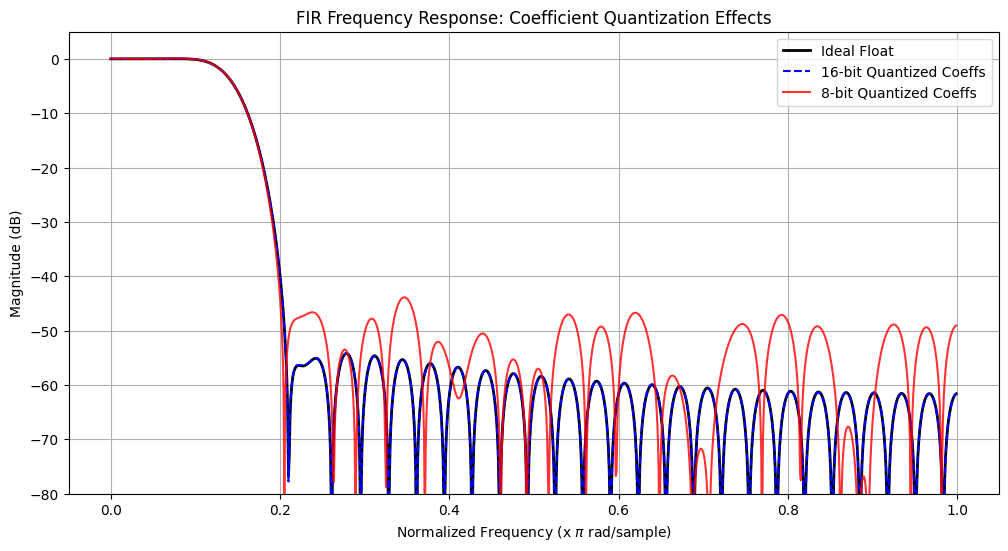

In [2]:
# 1. Design a Lowpass FIR Filter
num_taps = 61
cutoff_freq = 0.15 # normalized cutoff frequency
h_float = signal.firwin(num_taps, cutoff_freq)

# 2. Quantize coefficients to 16-bit (Q0.15 since max coefficient is < 1.0)
# Scale factor: scale h such that maximum value maps to the maximum representable integer
scale_16 = (2**15 - 1) / np.max(np.abs(h_float))
h_q16_int = np.round(h_float * scale_16)
h_q16 = h_q16_int / scale_16 # Convert back to float for spectral analysis

# 3. Quantize coefficients to 8-bit (Q0.7)
scale_8 = (2**7 - 1) / np.max(np.abs(h_float))
h_q8_int = np.round(h_float * scale_8)
h_q8 = h_q8_int / scale_8

# Compute Frequency Response
w_f, H_float = signal.freqz(h_float, 1, worN=1024)
_, H_q16 = signal.freqz(h_q16, 1, worN=1024)
_, H_q8 = signal.freqz(h_q8, 1, worN=1024)

# Plotting Frequency Responses
plt.figure(figsize=(12, 6))
plt.plot(w_f / np.pi, 20 * np.log10(np.abs(H_float) + 1e-10), 'black', label='Ideal Float', linewidth=2)
plt.plot(w_f / np.pi, 20 * np.log10(np.abs(H_q16) + 1e-10), 'blue', label='16-bit Quantized Coeffs', linestyle='--')
plt.plot(w_f / np.pi, 20 * np.log10(np.abs(H_q8) + 1e-10), 'red', label='8-bit Quantized Coeffs', alpha=0.8)

plt.title("FIR Frequency Response: Coefficient Quantization Effects")
plt.xlabel("Normalized Frequency (x $\pi$ rad/sample)")
plt.ylabel("Magnitude (dB)")
plt.ylim(-80, 5)
plt.legend()
plt.grid(True)
plt.show()

### Observation:
- **16-bit Quantization** (blue dashed line) is nearly identical to the floating-point ideal.
- **8-bit Quantization** (red line) shows severe stopband degradation. The stopband attenuation degrades from **-60 dB** to **-35 dB** (a significant leak of high-frequency noise). This is because the small coefficient values are rounded to zero or coarse values.

## 3. Real-Time Streaming DSP: Circular Buffer Implementation
In offline/batch signal processing, we process arrays of data at once using `np.convolve`. However, in real-world embedded systems, the ADC provides sample-by-sample values. 

To compute an $N$-tap FIR filter on a stream of samples, we need the current sample and the previous $N-1$ samples. Rather than shifting all samples in memory for each new incoming sample ($O(N)$ memory copies), we implement a **Circular Buffer** where a pointer wraps around, giving $O(1)$ updates.

Let's write a python circular buffer class and simulate real-time filtering.

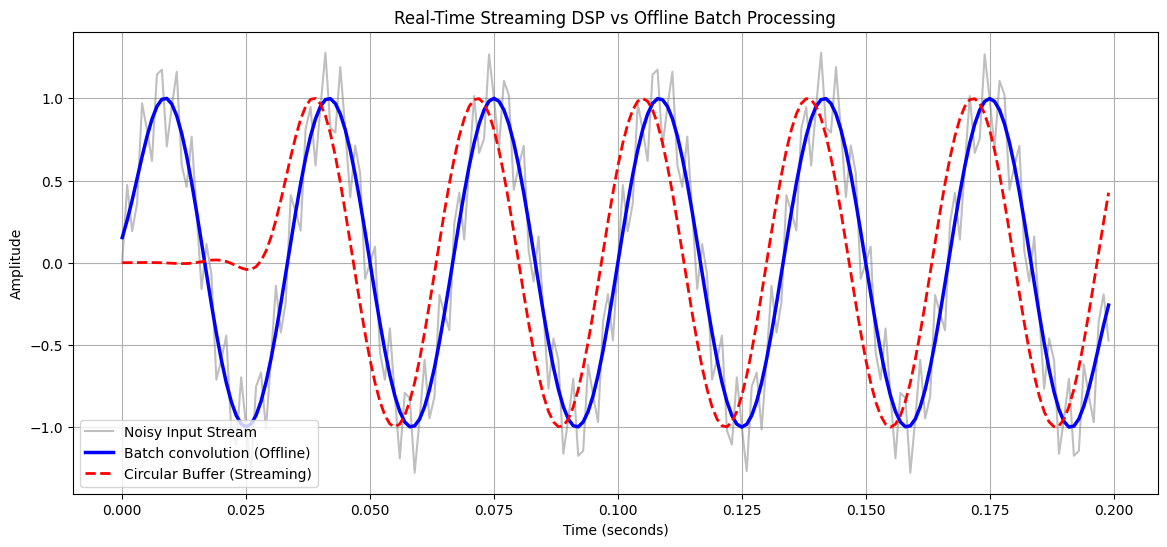

In [3]:
class CircularBuffer:
    def __init__(self, size):
        self.size = size
        self.buffer = np.zeros(size)
        self.index = 0  # Write pointer

    def insert(self, value):
        self.buffer[self.index] = value
        # Advance and wrap around write pointer
        self.index = (self.index + 1) % self.size

    def get_ordered_samples(self):
        # Return samples from oldest to newest
        # Oldest samples start from the current write pointer index
        return np.roll(self.buffer, -self.index)

# 1. Create a Circular Buffer for our FIR filter coefficients (length = num_taps)
cb = CircularBuffer(num_taps)

# Generate a noisy streaming signal (sine wave + high freq noise)
fs_stream = 1000.0
t_stream = np.arange(0, 0.2, 1/fs_stream)
clean_signal = np.sin(2 * np.pi * 30 * t_stream)
noisy_signal = clean_signal + 0.3 * np.sin(2 * np.pi * 300 * t_stream)

# 2. Perform Real-time Sample-by-Sample Filtering
stream_filtered = []

for sample in noisy_signal:
    # Insert new sample into circular buffer
    cb.insert(sample)
    
    # Get samples from oldest to newest
    buffered_samples = cb.get_ordered_samples()
    
    # Compute FIR filter output: sum(h * x)
    # Note: Coefficients are reversed for convolution
    output_val = np.sum(h_float[::-1] * buffered_samples)
    stream_filtered.append(output_val)

stream_filtered = np.array(stream_filtered)

# 3. Compare with offline convolve (standard batch processing)
batch_filtered = np.convolve(noisy_signal, h_float, mode='same')

# Plotting Streaming vs Batch result
plt.figure(figsize=(14, 6))
plt.plot(t_stream, noisy_signal, 'gray', alpha=0.5, label='Noisy Input Stream')
plt.plot(t_stream, batch_filtered, 'blue', linewidth=2.5, label='Batch convolution (Offline)')
plt.plot(t_stream, stream_filtered, 'red', linestyle='--', linewidth=2, label='Circular Buffer (Streaming)')
plt.title("Real-Time Streaming DSP vs Offline Batch Processing")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

## ✅ Reflection & Exercises
- **Filter Stability**: For Infinite Impulse Response (IIR) filters, quantizing coefficients can shift the poles outside the unit circle ($|z| > 1$). What happens to the filter's output if a pole shifts outside the unit circle?
- **Fixed-Point Multiplication**: When multiplying two $Q_{I.F}$ numbers, why does the result have $2F$ fractional bits? What operation must be performed to convert the product back to $Q_{I.F}$ format?